In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import os

# --- Configuration ---
TEST_DIR = "dataset"  # Folder containing test images
BATCH_SIZE = 32

print("Libraries loaded. Configuration set.")

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Libraries loaded. Configuration set.


In [2]:
def evaluate_specific_model(model_filename):
    print(f"\n{'='*40}")
    print(f"Loading and Testing: {model_filename}")
    print(f"{'='*40}")
    
    # Check if file exists
    if not os.path.exists(model_filename):
        print(f"Error: The file '{model_filename}' was not found.")
        return None, None

    # Load the model
    try:
        model = load_model(model_filename)
    except Exception as e:
        print(f"Error loading model: {e}")
        return None, None

    # Detect Input Shape Dynamically
    # model.input_shape looks like (None, Height, Width, Channels)
    input_shape = model.input_shape
    required_height = input_shape[1]
    required_width = input_shape[2]
    required_channels = input_shape[3]
    
    target_size = (required_height, required_width)
    
    # Determine color mode
    if required_channels == 1:
        color_mode = "grayscale"
    else:
        color_mode = "rgb"

    print(f" -> Model type detected. Required Input: {target_size}")
    print(f" -> Required Color Mode: {color_mode}")

    # Create Data Generator specific to this model
    test_datagen = ImageDataGenerator(rescale=1./255)
    
    test_generator = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=target_size, 
        color_mode=color_mode,   
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )

    if test_generator.samples > 0:
        loss, accuracy = model.evaluate(test_generator, verbose=1)
        print(f"\nRESULT for {model_filename}:")
        print(f"Test Accuracy: {round(accuracy * 100, 2)}%")
        print(f"Test Loss: {round(loss, 4)}")
    else:
        print("No images found in test directory.")
        
    return model, test_generator

def predict_single_image(model, img_path, class_names):
    if model is None: return

    h, w = model.input_shape[1], model.input_shape[2]
    c = model.input_shape[3]
    mode = "grayscale" if c == 1 else "rgb"

  
    img = image.load_img(img_path, target_size=(h, w), color_mode=mode)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)
    predicted_idx = np.argmax(prediction)
    confidence = np.max(prediction)
    
    print(f"Model ({h}x{w}) predicts: {class_names[predicted_idx]} ({confidence*100:.2f}%)")

In [3]:
from tensorflow.keras.models import load_model

# Load Transfer Model (224x224)
model_transfer = load_model("model_transfer.h5") 

# Load CNN Model (64x64)
model_cnn = load_model("model_cnn.h5")

# Define the image you want to test
img_path = "dataset/test (1).jpg" 
class_names = ['Cat', 'Dog', 'Chicken', 'Rabbit'] 


print(f"--- Predicting: {img_path} ---\n")

print("1. Transfer Learning Model:")
predict_single_image(model_transfer, img_path, class_names)

print("\n2. Custom CNN Model:")
predict_single_image(model_cnn, img_path, class_names)

--- Predicting: dataset/test (1).jpg ---

1. Transfer Learning Model:
Model (224x224) predicts: Dog (99.64%)

2. Custom CNN Model:
Model (64x64) predicts: Rabbit (38.98%)


In [4]:
# Define the image to test
img_path_to_test = "test (3).jpg"  

if os.path.exists(img_path_to_test) and gen_transfer is not None:

    class_names = list(gen_transfer.class_indices.keys())
    
    print(f"--- Predicting: {img_path_to_test} ---\n")
    
    print("1. Transfer Learning Model:")
    predict_single_image(model_transfer, img_path_to_test, class_names)
    
    print("\n2. Custom CNN Model:")

    predict_single_image(model_cnn, img_path_to_test, class_names)

else:
    print("Image not found or models not loaded successfully.")

Image not found or models not loaded successfully.


Found 320 images belonging to 4 classes.
Generating predictions for model input (64, 64)...
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 585ms/step
Found 320 images belonging to 4 classes.
Generating predictions for model input (224, 224)...
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 726ms/step


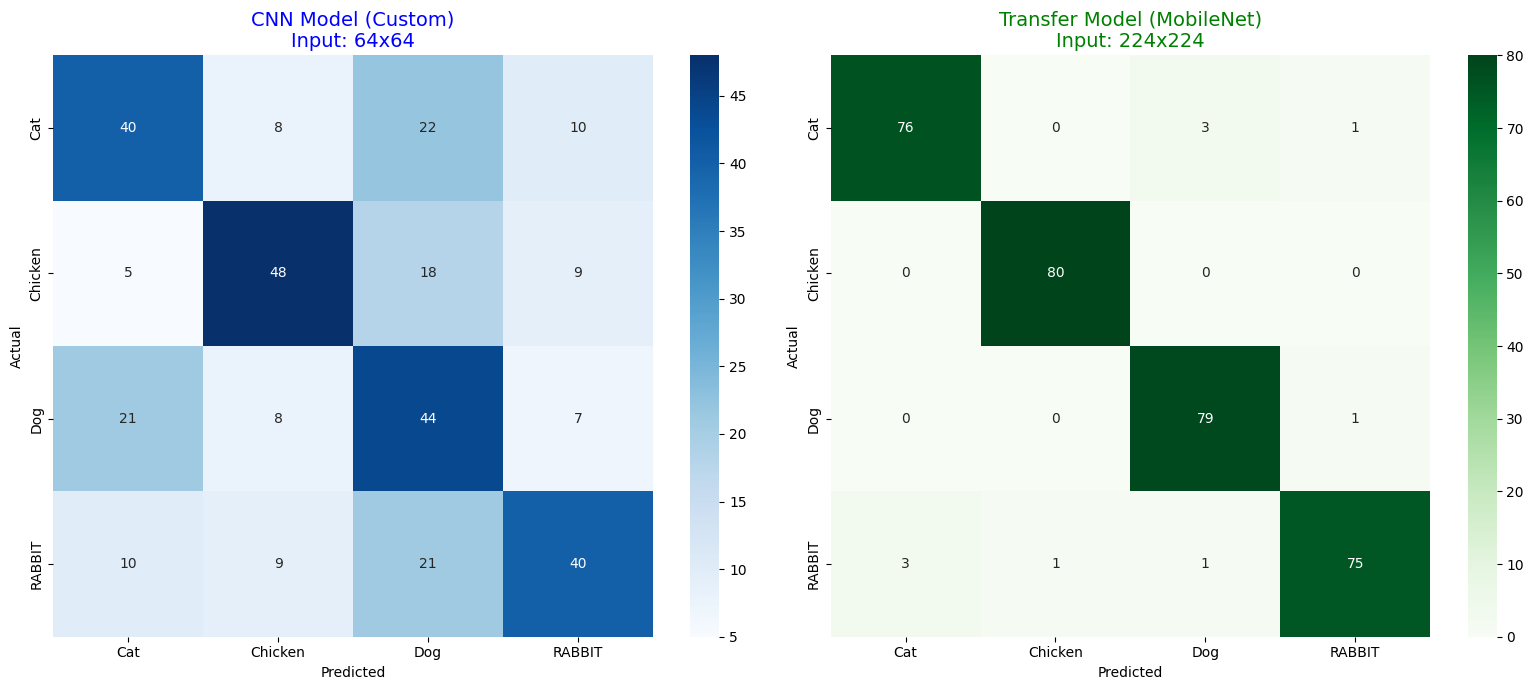

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def plot_comparison_heatmaps(test_dir, model_cnn, model_transfer, batch_size=32):
    
  
    def get_model_metrics(model, target_size):
        # Create a FRESH generator to ensure order is correct (shuffle=False is critical)
        datagen = ImageDataGenerator(rescale=1./255)
        
        # Determine color mode based on model input channels
        channels = model.input_shape[3]
        color_mode = "grayscale" if channels == 1 else "rgb"
        
        generator = datagen.flow_from_directory(
            test_dir,
            target_size=target_size,
            color_mode=color_mode,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=False  
        )

        # Predict
        print(f"Generating predictions for model input {target_size}...")
        y_pred_probs = model.predict(generator, verbose=1)
        y_pred = np.argmax(y_pred_probs, axis=1)
        
        # Get True Labels
        y_true = generator.classes
        class_names = list(generator.class_indices.keys())
        
        return y_true, y_pred, class_names

    # Get input size from model
    h_cnn, w_cnn = model_cnn.input_shape[1], model_cnn.input_shape[2]
    y_true_cnn, y_pred_cnn, classes_cnn = get_model_metrics(model_cnn, (h_cnn, w_cnn))
    
    # --- Get Metrics for Transfer Model (224x224) ---
    h_mob, w_mob = model_transfer.input_shape[1], model_transfer.input_shape[2]
    y_true_mob, y_pred_mob, classes_mob = get_model_metrics(model_transfer, (h_mob, w_mob))

    # --- Compute Confusion Matrices ---
    cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
    cm_mob = confusion_matrix(y_true_mob, y_pred_mob)

    # --- Plot Side-by-Side Heatmaps ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Plot CNN Heatmap
    sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes_cnn, yticklabels=classes_cnn, ax=axes[0])
    axes[0].set_title(f'CNN Model (Custom)\nInput: {h_cnn}x{w_cnn}', fontsize=14, color='blue')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    # Plot Transfer Heatmap
    sns.heatmap(cm_mob, annot=True, fmt='d', cmap='Greens', 
                xticklabels=classes_mob, yticklabels=classes_mob, ax=axes[1])
    axes[1].set_title(f'Transfer Model (MobileNet)\nInput: {h_mob}x{w_mob}', fontsize=14, color='green')
    axes[1].set_ylabel('Actual')
    axes[1].set_xlabel('Predicted')

    plt.tight_layout()
    plt.show()

# ==========================================
# EXECUTION
# ==========================================

#  Folder containing test images
test_folder = "final_data/test" 

#  Run the Heatmap Comparison
# Ensure models are loaded before running this
if 'model_cnn' in globals() and 'model_transfer' in globals():
    plot_comparison_heatmaps(test_folder, model_cnn, model_transfer)
else:
    print("Error: Models not loaded. Please run the model loading cells first.")

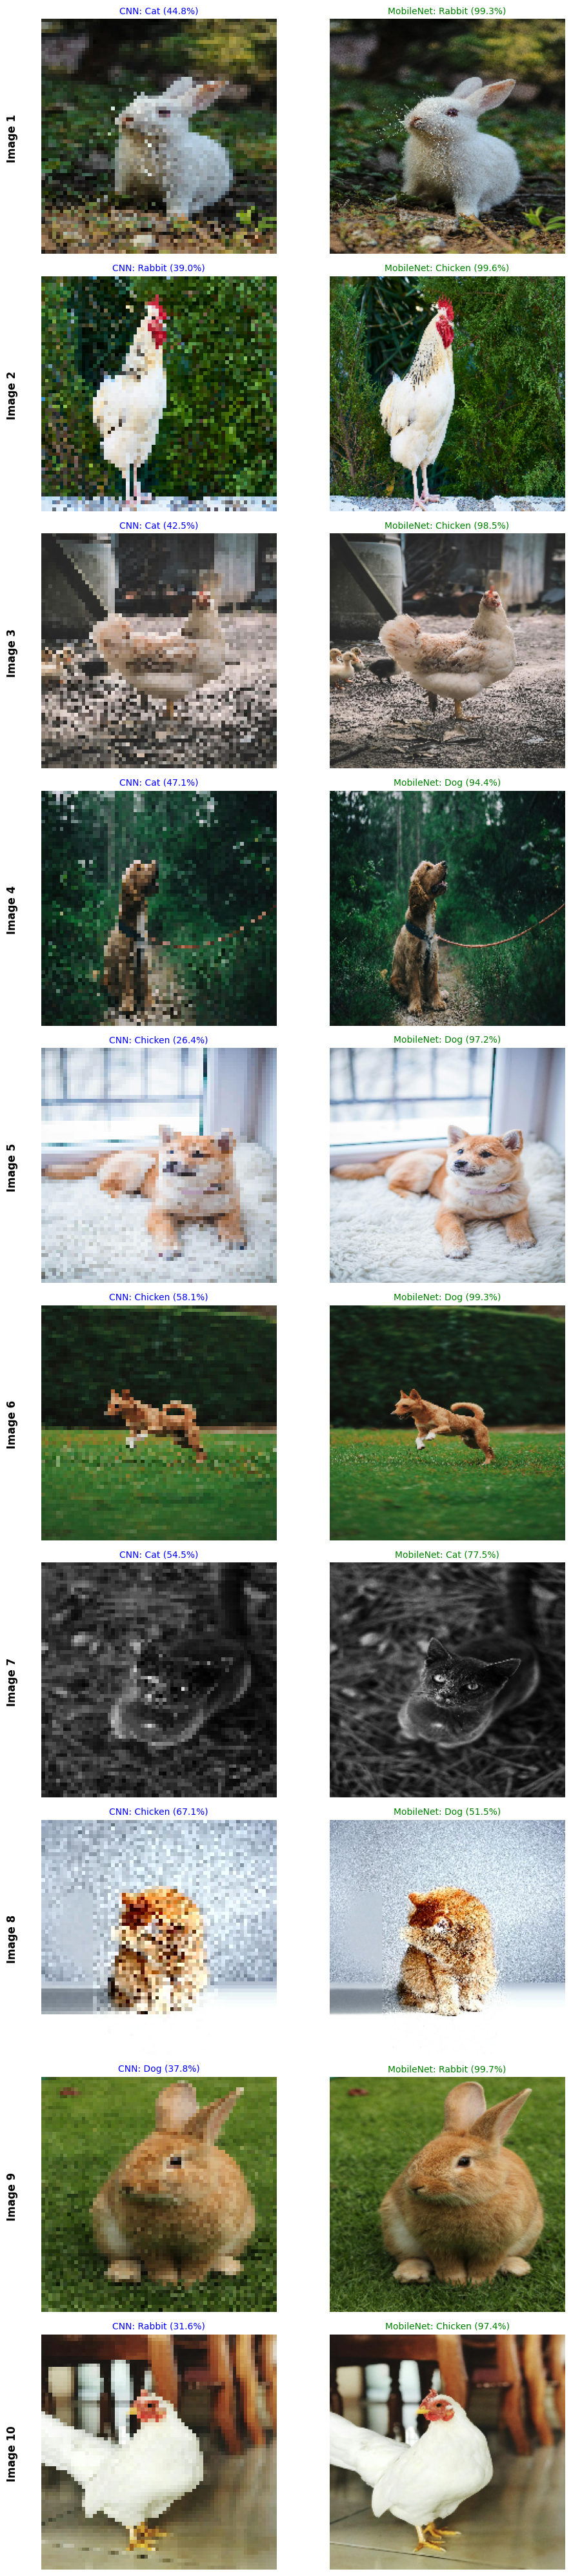

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import os
import random
from tensorflow.keras.preprocessing import image

def predict_multiple_images(test_dir, model_cnn, model_mobilenet, class_names, num_images=5):
    
    
    all_image_paths = []
    for root, dirs, files in os.walk(test_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_image_paths.append(os.path.join(root, file))
    
  
    if not all_image_paths:
        print(f"No images found in {test_dir}")
        return
        
    selected_paths = random.sample(all_image_paths, min(len(all_image_paths), num_images))
    
    def process_for_model(model, path):
        h, w = model.input_shape[1], model.input_shape[2]
        c = model.input_shape[3]
        color_mode = "grayscale" if c == 1 else "rgb"
        
        img = image.load_img(path, target_size=(h, w), color_mode=color_mode)
        img_arr = image.img_to_array(img) / 255.0
        img_batch = np.expand_dims(img_arr, axis=0)
        
        preds = model.predict(img_batch, verbose=0)
        return img_arr, class_names[np.argmax(preds)], np.max(preds), color_mode

    
    fig, axes = plt.subplots(len(selected_paths), 2, figsize=(10, 4 * len(selected_paths)))
    
    if len(selected_paths) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, img_path in enumerate(selected_paths):

        img_cnn, pred_cnn, conf_cnn, mode_cnn = process_for_model(model_cnn, img_path)
        img_mob, pred_mob, conf_mob, mode_mob = process_for_model(model_mobilenet, img_path)
        
        ax_cnn = axes[i, 0]
        if mode_cnn == "grayscale":
            ax_cnn.imshow(img_cnn.reshape(img_cnn.shape[0], img_cnn.shape[1]), cmap='gray')
        else:
            ax_cnn.imshow(img_cnn)
        ax_cnn.set_title(f"CNN: {pred_cnn} ({conf_cnn*100:.1f}%)", color="blue", fontsize=10)
        ax_cnn.axis("off")
        
        # Plot MobileNet (Right Column)
        ax_mob = axes[i, 1]
        if mode_mob == "grayscale":
            ax_mob.imshow(img_mob.reshape(img_mob.shape[0], img_mob.shape[1]), cmap='gray')
        else:
            ax_mob.imshow(img_mob)
        ax_mob.set_title(f"MobileNet: {pred_mob} ({conf_mob*100:.1f}%)", color="green", fontsize=10)
        ax_mob.axis("off")
        
        # Add label to the side
        ax_cnn.text(-10, 32, f"Image {i+1}", rotation=90, va='center', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

# ==========================================
# EXECUTION
# ==========================================

test_folder = "dataset"  


class_names = ['Cat', 'Chicken', 'Dog', 'Rabbit']

predict_multiple_images(test_folder, model_cnn, model_transfer, class_names, num_images=10)